# <u> Hypothesis Testing and Statistical Analysis for Fly Emirates <u>

In [14]:
pip install scikit_posthocs

Note: you may need to restart the kernel to use updated packages.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin 
import scikit_posthocs as sp
from scipy.stats import mannwhitneyu


In [3]:
df = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Projects/Fly Emirates/Dataset/flights.csv', low_memory = False)
df2 = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Projects/Fly Emirates/Dataset/airports.csv')
df3 = pd.read_csv('C:/Users/Adity/Desktop/Aditya/Projects/Fly Emirates/Dataset/airlines.csv')

In [4]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


# 1. Problem Statement: Do airlines differ significantly in arrival delays?

### Null Hypothesis (H₀): There is no significant difference in arrival delays among airlines.

### Alternative Hypothesis (H₁): At least one airline has a significantly different arrival delay distribution compared to the others.

In [5]:
for col in df.select_dtypes(include='float'):
    if (df[col].dropna() % 1 == 0).all():
        df[col] = df[col].astype('Int64')

df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408,-22,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741,-9,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811,5,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756,-9,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259,-21,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>


# Taking A Sample from this Dataset using Stratified Sampling`

In [6]:
sample_df = (
    df.groupby('AIRLINE', group_keys=False)
      .apply(lambda x: x.sample(frac=0.02, random_state=42))
      .reset_index(drop=True)
)

C:\Users\Adity\AppData\Local\Temp\ipykernel_13076\3545673232.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.02, random_state=42))


### Cross-Checking

<Axes: >

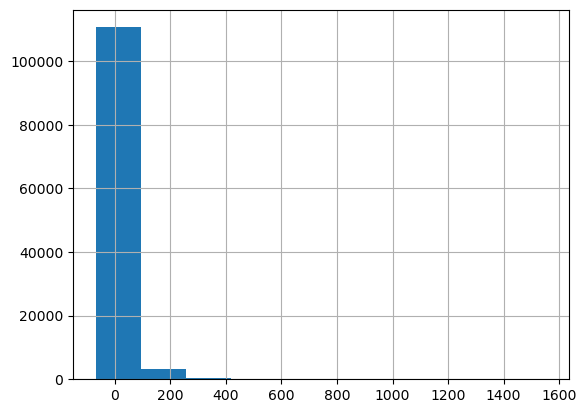

In [11]:
sample_df['ARRIVAL_DELAY'].hist()

In [7]:
sample_df['AIRLINE'].value_counts(normalize = True).round(4)

AIRLINE
WN    0.2168
DL    0.1505
AA    0.1248
OO    0.1011
EV    0.0983
UA    0.0886
MQ    0.0506
B6    0.0459
US    0.0341
AS    0.0296
NK    0.0202
F9    0.0156
HA    0.0131
VX    0.0106
Name: proportion, dtype: float64

In [8]:
df['AIRLINE'].value_counts(normalize = True).round(4)

AIRLINE
WN    0.2168
DL    0.1505
AA    0.1248
OO    0.1011
EV    0.0983
UA    0.0886
MQ    0.0506
B6    0.0459
US    0.0341
AS    0.0296
NK    0.0202
F9    0.0156
HA    0.0131
VX    0.0106
Name: proportion, dtype: float64

In [9]:
pingouin.kruskal(data = sample_df, dv = 'ARRIVAL_DELAY', between = 'AIRLINE')

,Source,ddof1,H,p_unc
Kruskal,AIRLINE,13,1392.881278,5.245114e-290


### Since the p-value (5.25 × 10⁻²⁹⁰) is significantly less than the significance level of 0.05, the null hypothesis is rejected.

### Conclusion: There is strong statistical evidence that arrival delay distributions differ among airlines. Therefore, airline choice appears to have a significant impact on arrival delays.

### Business Insight

### Although the test confirms statistically significant differences among airlines, the magnitude of these differences should be further examined using median arrival delays and post-hoc pairwise comparisons. This will help identify which airlines consistently experience higher or lower arrival delays and whether the observed differences are operationally meaningful.

In [20]:
dunn_results = sp.posthoc_dunn(
    sample_df,
    val_col='ARRIVAL_DELAY',
    group_col='AIRLINE',
    p_adjust='holm'
)

dunn_results

,AA,AS,B6,DL,EV,F9,HA,MQ,NK,OO,UA,US,VX,WN
AA,1.000000e+00,1.000000e+00,1.560230e-06,5.856348e-25,3.220116e-22,2.535024e-21,2.894521e-32,1.504741e-02,8.641058e-66,9.846874e-25,1.000000e+00,1.614774e-12,2.636876e-05,3.685467e-40
AS,1.000000e+00,1.000000e+00,8.816191e-05,5.395044e-07,1.431841e-11,1.117001e-17,5.017316e-27,3.541857e-02,2.871972e-49,1.304127e-12,1.000000e+00,3.617603e-09,3.872235e-05,3.055573e-16
B6,1.560230e-06,8.816191e-05,1.000000e+00,1.528994e-38,3.749406e-01,2.592600e-07,9.878749e-15,1.000000e+00,1.131552e-31,1.597329e-01,1.960128e-04,3.749406e-01,9.655526e-01,1.031665e-02
DL,5.856348e-25,5.395044e-07,1.528994e-38,1.000000e+00,2.079703e-91,2.920225e-48,1.680288e-61,4.443207e-28,1.140448e-115,1.029371e-97,1.520824e-24,4.448249e-46,5.694409e-18,9.700280e-155
EV,3.220116e-22,1.431841e-11,3.749406e-01,2.079703e-91,1.000000e+00,8.816191e-05,1.069172e-11,2.256849e-04,1.276463e-28,1.000000e+00,1.593102e-15,1.000000e+00,1.000000e+00,1.000000e+00
F9,2.535024e-21,1.117001e-17,2.592600e-07,2.920225e-48,8.816191e-05,1.000000e+00,3.749406e-01,4.930587e-11,1.788517e-04,2.113970e-04,1.733496e-18,3.112881e-03,1.597329e-01,4.881188e-04
HA,2.894521e-32,5.017316e-27,9.878749e-15,1.680288e-61,1.069172e-11,3.749406e-01,1.000000e+00,1.562133e-19,9.655526e-01,4.272421e-11,7.512333e-29,1.222519e-08,9.078202e-05,9.118524e-11
MQ,1.504741e-02,3.541857e-02,1.000000e+00,4.443207e-28,2.256849e-04,4.930587e-11,1.562133e-19,1.000000e+00,4.860245e-40,4.629861e-05,2.187077e-01,1.900601e-03,6.774455e-02,1.148731e-07
NK,8.641058e-66,2.871972e-49,1.131552e-31,1.140448e-115,1.276463e-28,1.788517e-04,9.655526e-01,4.860245e-40,1.000000e+00,1.427403e-27,1.442804e-58,4.395445e-20,3.411605e-10,3.718610e-28
OO,9.846874e-25,1.304127e-12,1.597329e-01,1.029371e-97,1.000000e+00,2.113970e-04,4.272421e-11,4.629861e-05,1.427403e-27,1.000000e+00,2.217904e-17,1.000000e+00,1.000000e+00,1.000000e+00


### Business Interpretation

### The Kruskal-Wallis test indicated that arrival delays vary significantly across airlines:

### H(13) = 1392.88
### p < 0.001

### Subsequent Dunn's post-hoc analysis revealed that while many airline pairs differ significantly in their arrival delay distributions, several groups of airlines exhibit statistically similar performance.

### For example:

### American Airlines (AA), Alaska Airlines (AS), and United Airlines (UA) do not differ significantly from one another. ExpressJet (EV), SkyWest (OO), US Airways (US), Virgin America (VX), and Southwest (WN) show similar arrival delay distributions. Hawaiian Airlines (HA) and Spirit Airlines (NK) also exhibit similar delay performance.

### This suggests that airlines can be clustered into groups with comparable operational reliability.

In [21]:
df.groupby('AIRLINE')['ARRIVAL_DELAY'].agg(
    median='median',
    mean='mean',
    count='count'
).sort_values('median')

,median,mean,count
AIRLINE,,,
DL,-8.0,0.186754,870275
AA,-6.0,3.451372,712935
MQ,-6.0,6.457873,278791
UA,-6.0,5.431594,507762
AS,-5.0,-0.976563,171439
B6,-5.0,6.677861,262042
EV,-4.0,6.585379,554752
OO,-4.0,5.845652,576814
US,-4.0,3.706209,194223


### A Kruskal-Wallis test revealed a statistically significant difference in arrival delay distributions among airlines (H(13) = 1392.88, p < 0.001). Post-hoc Dunn's tests showed that several airline pairs exhibited similar delay performance, while many others differed significantly. Examination of median arrival delays indicated that Delta Airlines (DL) demonstrated the best operational performance with a median arrival delay of -8 minutes, whereas Spirit Airlines (NK) exhibited the poorest performance with a median delay of 0 minutes. The substantial gap between mean and median delays across airlines suggests highly right-skewed delay distributions driven by a relatively small number of severely delayed flights.

# 2. Weekend Vs Weekday Analysis

## Hypotheses

### H₀: The distribution of arrival delays is the same for weekdays and weekends.

### H₁: The distribution of arrival delays differs between weekdays and weekends.

In [30]:
sample_df['WEEK_CATEGORY'] = np.where(sample_df['DAY_OF_WEEK'].isin([6,7]), 'Weekend', 'Weekday')

In [41]:
weekend = sample_df.loc[
    sample_df['WEEK_CATEGORY'] == 'Weekend',
    'ARRIVAL_DELAY'
].dropna()

weekday = sample_df.loc[
    sample_df['WEEK_CATEGORY'] == 'Weekday',
    'ARRIVAL_DELAY'
].dropna()

u_stat, p_value = mannwhitneyu(
    weekend,
    weekday,
    alternative='two-sided'
)

print(u_stat)
print(p_value)

1199635062.5
1.3214664916797538e-37


## Conclusion: Arrival delay distributions differ significantly between weekdays and weekends.

In [36]:
sample_df.groupby('WEEK_CATEGORY')['ARRIVAL_DELAY'].agg(
    median='median',
    mean='mean',
    count='count'
)

,median,mean,count
WEEK_CATEGORY,,,
Weekday,-5.0,5.003119,84319
Weekend,-6.0,3.046552,29945


### The Mann-Whitney U test revealed a statistically significant difference in arrival delays between weekday and weekend flights. Weekend flights demonstrated slightly better performance, with a median arrival delay of -6 minutes compared to -5 minutes for weekday flights. Weekend flights also exhibited a lower mean arrival delay (3.05 minutes) than weekday flights (5.00 minutes).

In [43]:
sample_df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,WEEK_CATEGORY
0,2015,2,25,3,AA,194,N020AA,ATL,DFW,1510,...,17,0,0,NaN,17,0,0,0,0,Weekday
1,2015,8,23,7,AA,2280,N3EXAA,MCO,DFW,1423,...,-25,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekend
2,2015,12,2,3,AA,2002,N836AW,DCA,CLT,1200,...,4,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekday
3,2015,9,11,5,AA,1964,N710UW,CLT,MCI,1135,...,-13,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekday
4,2015,11,10,2,AA,1459,N4UCAA,DFW,MCI,1820,...,-8,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekday


# 3. Cancellation Analysis

## Problem Statement: "Does cancellation depend on airline?"

## Hypotheses

### H₀: Airlines Cancelations Status are Independent.

### H₁: Airlines Cancellation Status are Not Independent.

In [47]:
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116382 entries, 0 to 116381
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   YEAR                 116382 non-null  int64 
 1   MONTH                116382 non-null  int64 
 2   DAY                  116382 non-null  int64 
 3   DAY_OF_WEEK          116382 non-null  int64 
 4   AIRLINE              116382 non-null  object
 5   FLIGHT_NUMBER        116382 non-null  int64 
 6   TAIL_NUMBER          116091 non-null  object
 7   ORIGIN_AIRPORT       116382 non-null  object
 8   DESTINATION_AIRPORT  116382 non-null  object
 9   SCHEDULED_DEPARTURE  116382 non-null  int64 
 10  DEPARTURE_TIME       114643 non-null  Int64 
 11  DEPARTURE_DELAY      114643 non-null  Int64 
 12  TAXI_OUT             114592 non-null  Int64 
 13  WHEELS_OFF           114592 non-null  Int64 
 14  SCHEDULED_TIME       116382 non-null  Int64 
 15  ELAPSED_TIME         114264 non-nu

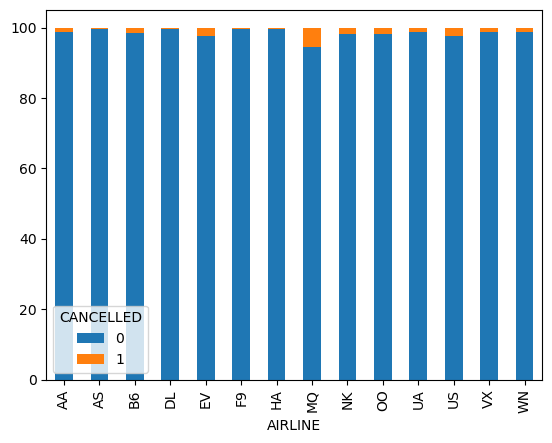

In [50]:
props = sample_df.groupby('AIRLINE')['CANCELLED'].value_counts(normalize = True) * 100
wide_props = props.unstack()
wide_props.plot(kind = 'bar', stacked = True)
plt.show()

In [53]:
expected, observed, stats = pingouin.chi2_independence(data = sample_df, x = 'AIRLINE', y = 'CANCELLED', correction = True)
print(stats[stats['test'] == 'pearson'])

      test  lambda        chi2   dof           pval    cramer  power
0  pearson     1.0  910.463118  13.0  2.895822e-186  0.088448    1.0


### A Chi-Square Test of Independence was conducted to examine the relationship between airline and flight cancellation status. The results indicated a statistically significant association, χ²(13) = 910.46, p < 0.001. However, the effect size was very weak (Cramér's V = 0.088), suggesting that airline explains only a small portion of cancellation behavior. Analysis of cancellation rates showed that some airlines experienced cancellation rates above the industry average, while others exhibited below-average cancellation frequencies.

In [66]:
categorizing = (sample_df.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending = False) * 100)
categorizing
overall_c = sample_df['CANCELLED'].mean() * 100 
analysis = categorizing - overall_c 
analysis
residual = (observed - expected) / np.sqrt(expected)
residual
summary = pd.DataFrame({
    'cancel_rate_pct': categorizing,
    'diff_from_avg': analysis,
    'cancel_residual': residual[1]
}).sort_values('cancel_rate_pct', ascending=False)

summary

,cancel_rate_pct,diff_from_avg,cancel_residual
AIRLINE,,,
MQ,5.531987,3.980201,24.527723
EV,2.438811,0.887025,7.616103
US,2.315048,0.763261,3.862525
NK,1.916525,0.364738,1.418778
OO,1.827144,0.275357,2.397803
B6,1.516570,-0.035216,-0.206605
UA,1.347683,-0.204104,-1.663981
WN,1.291754,-0.260032,-3.316118
AA,1.225895,-0.325891,-3.152389


### Among all airlines, MQ exhibited the highest cancellation rate at 5.53%, which is approximately 3.6 times higher than the industry average. MQ and EV were identified as the primary contributors to the significant Chi-Square statistic, indicating substantially more cancellations than expected under independence.

### Alaska Airlines (AS) achieved the lowest cancellation rate at 0.29%, approximately 81% lower than the industry average. Delta Airlines (DL) also demonstrated strong operational reliability with a cancellation rate of only 0.50%.

## <u> Business Insight <u>

### Although airline carrier is statistically associated with flight cancellations, the overall effect is weak. Most airlines exhibit cancellation rates close to the industry average, and the significant relationship is primarily driven by a small number of carriers with unusually high or low cancellation frequencies.

### From an operational perspective, MQ and EV represent the highest cancellation-risk carriers, while AS and DL demonstrate the strongest cancellation performance and operational reliability. These findings suggest that airline-specific operational practices may influence cancellation outcomes, but additional factors such as weather conditions, airport congestion, route networks, and seasonal demand are likely to play a larger role in explaining cancellation behavior.

# 4. Month Wise ARRIVAL/DEPARTURE Delay

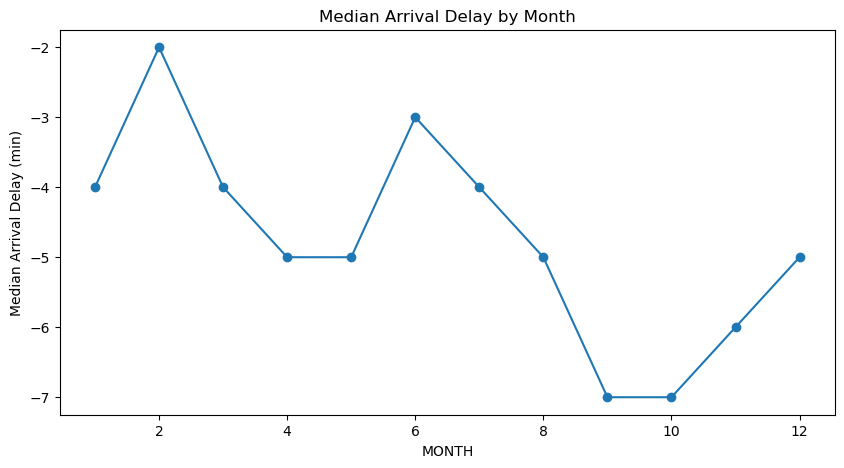

In [102]:
month_delay = (
    sample_df.groupby('MONTH')['ARRIVAL_DELAY']
    .median()
)
month_delay.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.ylabel('Median Arrival Delay (min)')
plt.title('Median Arrival Delay by Month')
plt.show()

In [86]:
pingouin.kruskal(data = sample_df, dv = 'ARRIVAL_DELAY', between = 'MONTH')

,Source,ddof1,H,p_unc
Kruskal,MONTH,11,1107.025966,1.742300e-230


In [101]:
month_summary = (
    sample_df.groupby('MONTH')['ARRIVAL_DELAY']
    .agg(
        median='median',
        mean='mean',
        count='count'
    )
)
month_summary.sort_values('MONTH')

,median,mean,count
MONTH,,,
1,-4.0,5.237492,9154
2,-2.0,8.545712,8116
3,-4.0,5.511798,9832
4,-5.0,3.244498,9542
5,-5.0,4.986791,9842
6,-3.0,9.205835,9940
7,-4.0,6.623688,10292
8,-5.0,4.380048,10054
9,-7.0,-0.871905,9329


### A Kruskal-Wallis test was conducted to examine whether arrival delays differed across months. The results indicated a statistically significant difference in arrival delay distributions among months (H(11) = 1107.03, p < 0.001). Analysis of monthly delay metrics revealed a clear seasonal pattern. September and October demonstrated the strongest operational performance, with median arrival delays of -7 minutes and average delays close to zero. In contrast, February and June exhibited the weakest performance, with median delays of -2 and -3 minutes and average delays of 8.55 and 9.21 minutes respectively. The difference between the best and worst performing months exceeded 10 minutes in terms of average delay, suggesting that seasonal factors such as adverse weather conditions, increased travel demand, and airport congestion contribute to variations in airline punctuality throughout the year.

# 5. Weather Impact

### Problem Statement: "Does weather significantly increase delays?"

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,WEEK_CATEGORY
0,2015,2,25,3,AA,194,N020AA,ATL,DFW,1510,...,17,0,0,NaN,17,0,0,0,0,Weekday
1,2015,8,23,7,AA,2280,N3EXAA,MCO,DFW,1423,...,-25,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekend
2,2015,12,2,3,AA,2002,N836AW,DCA,CLT,1200,...,4,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekday
3,2015,9,11,5,AA,1964,N710UW,CLT,MCI,1135,...,-13,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekday
4,2015,11,10,2,AA,1459,N4UCAA,DFW,MCI,1820,...,-8,0,0,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,Weekday


# 6. Diversion Analysis

### Problem Statement: "Are certain airlines more likely to divert flights?"

<Axes: xlabel='AIRLINE'>

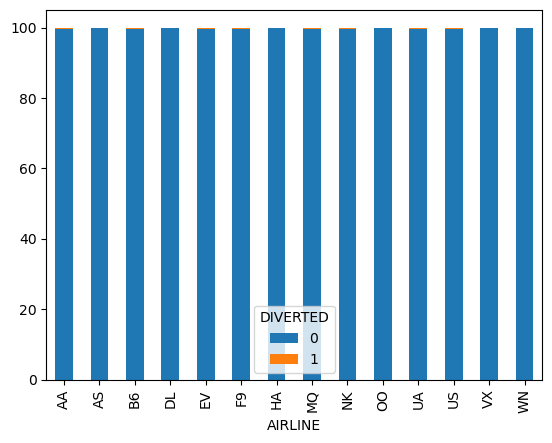

In [124]:
props = sample_df.groupby('AIRLINE')['DIVERTED'].value_counts(normalize = True) * 100
wide_props = props.unstack()
wide_props.plot(kind = 'bar', stacked = True)

### Diversions were extremely rare, affecting only 312 flights (0.27% of all flights). Airline-level diversion rates showed minor variation across carriers; however, due to the low frequency of diversion events and violation of Chi-Square assumptions, the analysis was limited to descriptive statistics rather than formal hypothesis testing.

# . Airport Congestion Analysis

### Problem Statement: "Do airports with higher traffic experience more delays?"

### Hypothesis (H₀): Airport traffic volume is not associated with arrival delays.

### Hypothesis (H₁): Airport traffic volume is associated with arrival delays.

In [146]:
airport_analysis = (
    sample_df.groupby('ORIGIN_AIRPORT')
    .agg(
        FLIGHT_COUNT=('ORIGIN_AIRPORT', 'size'),
        MEDIAN_DELAY=('ARRIVAL_DELAY', 'median'),
        MEAN_DELAY=('ARRIVAL_DELAY', 'mean')
    )
)

airport_analysis['TRAFFIC_GROUP'] = pd.qcut(
    airport_analysis['FLIGHT_COUNT'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

pingouin.kruskal(
    data=airport_analysis,
    dv='MEDIAN_DELAY',
    between='TRAFFIC_GROUP'
)


,Source,ddof1,H,p_unc
Kruskal,TRAFFIC_GROUP,3,8.005275,0.045903


### Airport traffic volume exhibited only a weak association with arrival delays (H(3)=8.01, p=0.046), suggesting congestion contributes to delays but is not a primary driver compared with factors such as airline operations, departure delays, or weather.

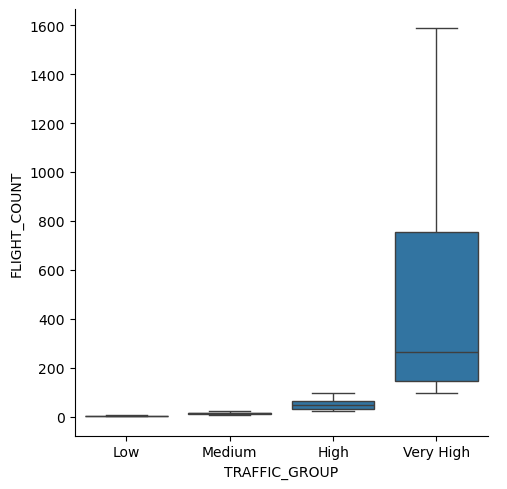

In [159]:
sns.catplot(x = 'TRAFFIC_GROUP', y = 'FLIGHT_COUNT', data = airport_analysis, kind = 'box', showfliers = False)

# 7. Cancellation Reason Analysis
### Problem Statement: What is the most common reason for flight cancellation?

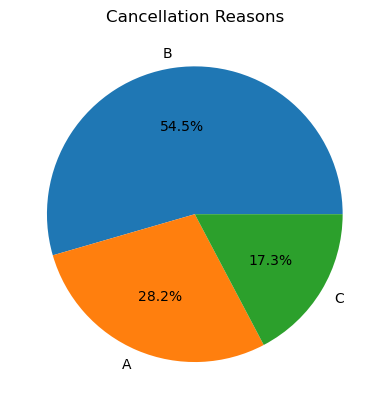

In [155]:
cancel_reason = (
    sample_df['CANCELLATION_REASON']
    .value_counts(normalize=True)
    * 100
)

plt.pie(
    cancel_reason,
    labels=cancel_reason.index,
    autopct='%1.1f%%'
)

plt.title('Cancellation Reasons')
plt.show()